In [97]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive


'Abirham Getie Data Commentary Draft.docx'
'Abirham_Getie_Resume (1).pdf'
 Abirham_Getie_Resume.pdf
 Abirham_Project_report_draft.docx
'AI-Powered Image Retrieval with Vector Databases.pptx'
'C_F_Resume (1).pdf'
 C_F_Resume.pdf
'Colab Notebooks'
'GW Data Science Resume and Cover Letter Guide.docx'
 NLP_Final_Project
 tree_assignment.py
'Unofficial Transcript.pdf'


In [101]:
project_path = "/content/drive/MyDrive/NLP_Final_Project"

In [102]:
!ls "$project_path"

best_lstm_model.keras	       processed
financial_news_headlines.csv   random_real_headlines.csv
labeled_partner_headlines.csv  raw_partner_headlines2.csv
models			       Sentences_AllAgree.txt


In [103]:
import os
os.chdir(project_path)
print("Current working directory:", os.getcwd())


Current working directory: /content/drive/MyDrive/NLP_Final_Project


In [104]:
import pandas as pd

df = pd.read_csv("raw_partner_headlines2.csv")
df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,2,Agilent Technologies Announces Pricing of $5……...,http://www.gurufocus.com/news/1153187/agilent-...,GuruFocus,2020-06-01 00:00:00,A
1,3,Agilent (A) Gears Up for Q2 Earnings: What's i...,http://www.zacks.com/stock/news/931205/agilent...,Zacks,2020-05-18 00:00:00,A
2,4,J.P. Morgan Asset Management Announces Liquida...,http://www.gurufocus.com/news/1138923/jp-morga...,GuruFocus,2020-05-15 00:00:00,A
3,5,"Pershing Square Capital Management, L.P. Buys ...",http://www.gurufocus.com/news/1138704/pershing...,GuruFocus,2020-05-15 00:00:00,A
4,6,Agilent Awards Trilogy Sciences with a Golden ...,http://www.gurufocus.com/news/1134012/agilent-...,GuruFocus,2020-05-12 00:00:00,A


In [105]:
import pandas as pd

# Path to the raw Kaggle file
path = "raw_partner_headlines2.csv"

df = pd.read_csv(path)

print("Shape (rows, columns):", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
print(df.info())


Shape (rows, columns): (1845559, 6)

Columns:
['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1845559 entries, 0 to 1845558
Data columns (total 6 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Unnamed: 0  int64 
 1   headline    object
 2   url         object
 3   publisher   object
 4   date        object
 5   stock       object
dtypes: int64(1), object(5)
memory usage: 84.5+ MB
None


In [ ]:
pip install transformers torch pandas tqdm

In [110]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification, pipeline,AutoModel
from tqdm.auto import tqdm

In [111]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
!nvidia-smi


Fri Dec  5 13:15:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             56W /  400W |       5MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [112]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
model = model.half().to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [113]:
label_map = model.config.id2label
print("CORRECT LABEL MAP:", label_map)

CORRECT LABEL MAP: {0: 'positive', 1: 'negative', 2: 'neutral'}


In [114]:

df["headline"] = df["headline"].astype(str)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
model = model.half().to(device)
model.eval()

label_map = model.config.id2label
print("CORRECT LABEL MAP:", label_map)
# {0:'positive', 1:'negative', 2:'neutral'}


def fast_finbert(headlines, batch_size=768):
    sentiments = []
    for i in tqdm(range(0, len(headlines), batch_size)):
        batch = headlines[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=48
        ).to(device)

        with torch.cuda.amp.autocast():
            with torch.no_grad():
                logits = model(**inputs).logits

        preds = torch.argmax(logits, dim=1).tolist()
        sentiments.extend([label_map[p] for p in preds])

    return sentiments

df["sentiment"] = fast_finbert(df["headline"].tolist())
df.to_csv("financial_news_headlines.csv",
          index=False)

print("DONE — Corrected labels saved.")


CORRECT LABEL MAP: {0: 'positive', 1: 'negative', 2: 'neutral'}


  0%|          | 0/2404 [00:00<?, ?it/s]

/tmp/ipython-input-2184819428.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


DONE — Corrected labels saved.


In [115]:
df=pd.read_csv("financial_news_headlines.csv")
df.head(20)

,Unnamed: 0,headline,url,publisher,date,stock,sentiment
0,2,Agilent Technologies Announces Pricing of $5……...,http://www.gurufocus.com/news/1153187/agilent-...,GuruFocus,2020-06-01,A,neutral
1,3,Agilent (A) Gears Up for Q2 Earnings: What's i...,http://www.zacks.com/stock/news/931205/agilent...,Zacks,2020-05-18,A,neutral
2,4,J.P. Morgan Asset Management Announces Liquida...,http://www.gurufocus.com/news/1138923/jp-morga...,GuruFocus,2020-05-15,A,negative
3,5,"Pershing Square Capital Management, L.P. Buys ...",http://www.gurufocus.com/news/1138704/pershing...,GuruFocus,2020-05-15,A,neutral
4,6,Agilent Awards Trilogy Sciences with a Golden ...,http://www.gurufocus.com/news/1134012/agilent-...,GuruFocus,2020-05-12,A,positive
5,7,Agilent Technologies Inc (A) CEO and President...,http://www.gurufocus.com/news/1132985/agilent-...,GuruFocus,2020-05-11,A,neutral
6,8,' Stocks Growing Their Earnings Fast,http://www.gurufocus.com/news/1129235/3-stocks...,GuruFocus,2020-05-07,A,positive
7,9,Cypress Asset Management Inc Buys Verizon Comm...,http://www.gurufocus.com/news/1128926/cypress-...,GuruFocus,2020-05-07,A,neutral
8,10,Hendley & Co Inc Buys American Electric Power ...,http://www.gurufocus.com/news/1126951/hendley-...,GuruFocus,2020-05-05,A,neutral
9,11,Teacher Retirement System Of Texas Buys Hologi...,http://www.gurufocus.com/news/1126799/teacher-...,GuruFocus,2020-05-05,A,neutral


In [116]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
label_map = model.config.id2label
print(label_map)

{0: 'positive', 1: 'negative', 2: 'neutral'}


In [117]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from collections import Counter
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import numpy as np

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [118]:
from transformers import AutoModel

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock', 'sentiment']
Number of rows: 1845559
PhraseBank rows: 2264
                                            sentence     label
0  According to Gran , the company has no plans t...   neutral
1  For the last quarter of 2010 , Componenta 's n...  positive
2  In the third quarter of 2010 , net sales incre...  positive
3  Operating profit rose to EUR 13.1 mn from EUR ...  positive
4  Operating profit totalled EUR 21.1 mn , up fro...  positive
Using device: cuda
FinBERT label map: {0: 'positive', 1: 'negative', 2: 'neutral'}

Running FinBERT on Financial PhraseBank...


  0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipython-input-3382822175.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):



 FinBERT on PhraseBank
Accuracy: 0.9717314487632509

Classification report:
               precision    recall  f1-score   support

    negative      0.906     0.983     0.943       303
     neutral      0.999     0.967     0.982      1391
    positive      0.947     0.977     0.962       570

    accuracy                          0.972      2264
   macro avg      0.951     0.976     0.963      2264
weighted avg      0.973     0.972     0.972      2264


Confusion matrix (rows=true, cols=pred):
[[ 298    1    4]
 [  19 1345   27]
 [  12    1  557]]
Label order: ['negative', 'neutral', 'positive']


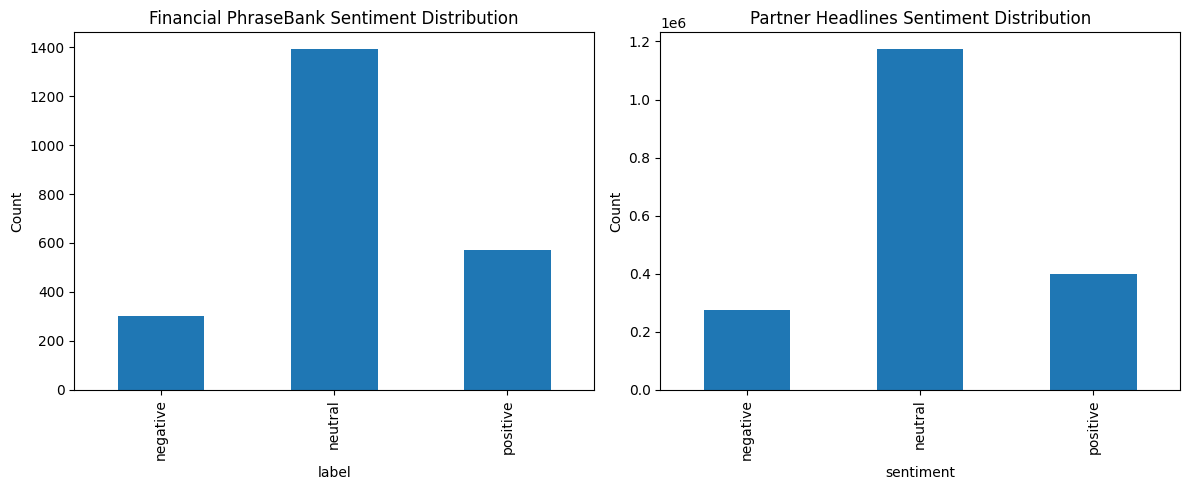


PhraseBank distribution (proportion):
label
negative    0.133834
neutral     0.614399
positive    0.251767
Name: count, dtype: float64

 dataset distribution (proportion):
sentiment
negative    0.149148
neutral     0.635462
positive    0.215391
Name: count, dtype: float64

Computing FinBERT confidences on your dataset (this may take a bit)...


  0%|          | 0/2404 [00:00<?, ?it/s]

/tmp/ipython-input-3382822175.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):



Mismatch rate between stored sentiment and fresh FinBERT preds: 0.0000


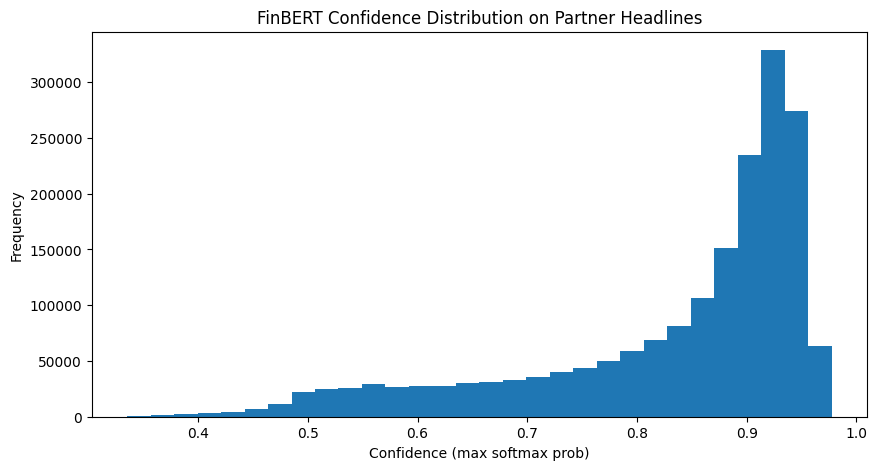


Confidence stats:
count    1.845559e+06
mean     8.335692e-01
std      1.301915e-01
min      3.352051e-01
25%      7.783203e-01
50%      8.896484e-01
75%      9.272461e-01
max      9.775391e-01
Name: confidence, dtype: float64

Number of low-confidence headlines (conf < 0.55): 103549

Sample low-confidence headlines:
                                              headline sentiment  confidence
69   Dow Jones Futures: Stock Market Fear Gauge Hit...  negative    0.457764
129  Trimble Strengthens Forestry Division With 3LO...   neutral    0.512695
155  Agilent Technologies Hitting Lower Rail Of Upw...  negative    0.548828
164     Agilent: Some Bolt-On M&A To Rejuvenate Growth  positive    0.518555
192                   Agilent Q2 2019 Earnings Preview   neutral    0.526855
230  Square (SQ) to Report Q1 Earnings: What's in t...   neutral    0.503418
237  Hedge Funds Have Never Been This Bullish On Xi...   neutral    0.540039
244                        6 Stocks Beating the Market   neutral

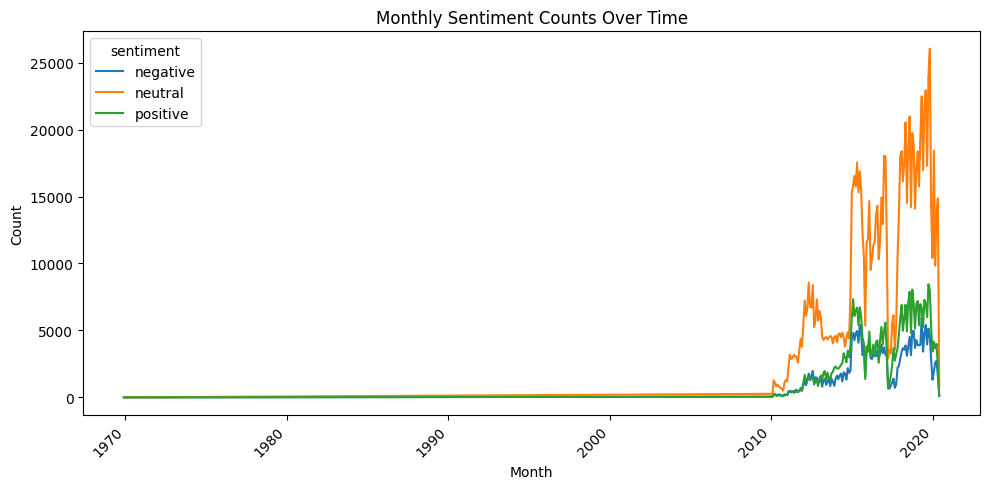


Publisher sentiment proportions (top 10 publishers):
sentiment                                            negative   neutral  \
publisher                 publisher                                       
Accesswire                Accesswire                 0.305843  0.401989   
BayStreet                 BayStreet                  0.397608  0.234976   
Born2Invest               Born2Invest                1.000000  0.000000   
Fox Business              Fox Business               0.200722  0.700361   
GuruFocus                 GuruFocus                  0.058531  0.823398   
Investopedia              Investopedia               0.065811  0.783501   
Investor's Business Daily Investor's Business Daily  0.218526  0.355860   
Marketfy                  Marketfy                   0.021186  0.940678   
Marketfy Insights         Marketfy Insights          0.011331  0.952471   
Seeking Alpha             Seeking Alpha              0.150962  0.664429   

sentiment                                    

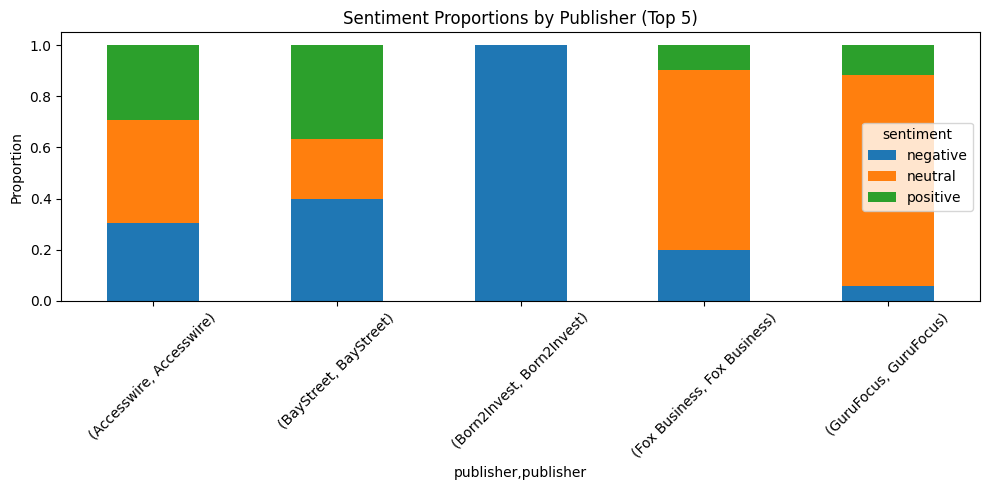

In [119]:

plt.rcParams["figure.figsize"] = (10, 5)
df = pd.read_csv("financial_news_headlines.csv")
print("Columns:", df.columns.tolist())
print("Number of rows:", len(df))

df["headline"] = df["headline"].astype(str)
df["date"] = pd.to_datetime(df["date"], errors="coerce")


phrasebank_path = "/content/drive/MyDrive/NLP_Final_Project/Sentences_AllAgree.txt"

df_pb = pd.read_csv(
    phrasebank_path,
    sep='@',
    header=None,
    names=['sentence', 'label'],
    engine='python',
    encoding='cp1252'
)

df_pb['sentence'] = df_pb['sentence'].astype(str).str.strip()
df_pb['label'] = df_pb['label'].astype(str).str.strip().str.lower()
print("PhraseBank rows:", len(df_pb))
print(df_pb.head())


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

finbert_name = "ProsusAI/finbert"
finbert_tokenizer = AutoTokenizer.from_pretrained(finbert_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_name)
if device.type == "cuda":
    finbert_model = finbert_model.half()
finbert_model.to(device)
finbert_model.eval()

label_map = finbert_model.config.id2label
print("FinBERT label map:", label_map)

def finbert_predict_with_probs(texts, batch_size=512, max_len=64):
    all_labels = []
    all_conf = []
    all_probs = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = finbert_tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len
        ).to(device)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            with torch.no_grad():
                logits = finbert_model(**inputs).logits

        probs = torch.softmax(logits, dim=-1)
        conf_vals, pred_ids = torch.max(probs, dim=1)

        labels = [label_map[int(i)] for i in pred_ids]
        all_labels.extend(labels)
        all_conf.extend(conf_vals.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

    return all_labels, all_conf, np.array(all_probs)


print("\nRunning FinBERT on Financial PhraseBank...")
pb_preds, pb_conf, pb_probs = finbert_predict_with_probs(df_pb["sentence"].tolist())

df_pb["finbert_label"] = pb_preds
df_pb["finbert_confidence"] = pb_conf

y_true = df_pb["label"]
y_pred = df_pb["finbert_label"]

print("\n FinBERT on PhraseBank")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=3))

labels_order = ["negative", "neutral", "positive"]
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred, labels=labels_order))
print("Label order:", labels_order)

pb_counts = df_pb["label"].value_counts().sort_index()
my_counts = df["sentiment"].value_counts().sort_index()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

pb_counts.plot(kind="bar", ax=axs[0])
axs[0].set_title("Financial PhraseBank Sentiment Distribution")
axs[0].set_ylabel("Count")

my_counts.plot(kind="bar", ax=axs[1])
axs[1].set_title("Partner Headlines Sentiment Distribution")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\nPhraseBank distribution (proportion):")
print(pb_counts / pb_counts.sum())
print("\n dataset distribution (proportion):")
print(my_counts / my_counts.sum())

print("\nComputing FinBERT confidences on your dataset (this may take a bit)...")
my_preds, my_conf, my_probs = finbert_predict_with_probs(df["headline"].tolist(), batch_size=768, max_len=48)

df["finbert_pred"] = my_preds
df["confidence"] = my_conf
mismatch_rate = (df["finbert_pred"] != df["sentiment"]).mean()
print(f"\nMismatch rate between stored sentiment and fresh FinBERT preds: {mismatch_rate:.4f}")


plt.hist(df["confidence"], bins=30)
plt.title("FinBERT Confidence Distribution on Partner Headlines")
plt.xlabel("Confidence (max softmax prob)")
plt.ylabel("Frequency")
plt.show()

print("\nConfidence stats:")
print(df["confidence"].describe())

low_conf_thr = 0.55
df_low_conf = df[df["confidence"] < low_conf_thr].copy()
print(f"\nNumber of low-confidence headlines (conf < {low_conf_thr}):", len(df_low_conf))

print("\nSample low-confidence headlines:")
print(df_low_conf[["headline", "sentiment", "confidence"]].head(10))

stops = set(stopwords.words("english"))

def top_words_for_label(df_in, label, n=20):
    text = " ".join(df_in[df_in["sentiment"] == label]["headline"].astype(str)).lower()
    tokens = [w for w in text.split() if w.isalpha() and w not in stops]
    counts = Counter(tokens)
    return counts.most_common(n)

for lab in ["positive", "negative", "neutral"]:
    if lab in df["sentiment"].unique():
        print(f"\nTop words for {lab.upper()}:")
        print(top_words_for_label(df, lab, n=20))
df_time = df.dropna(subset=["date"]).copy()
df_time["year_month"] = df_time["date"].dt.to_period("M")

sent_by_month = df_time.groupby(["year_month", "sentiment"]).size().unstack(fill_value=0)
sent_by_month.index = sent_by_month.index.to_timestamp()

sent_by_month.plot()
plt.title("Monthly Sentiment Counts Over Time")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

publisher_sent = (
    df.groupby(["publisher", "sentiment"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack(fill_value=0)
)

print("\nPublisher sentiment proportions (top 10 publishers):")
print(publisher_sent.head(10))

top_publishers = publisher_sent.index[:5]
publisher_sent.loc[top_publishers].plot(kind="bar", stacked=True)
plt.title("Sentiment Proportions by Publisher (Top 5)")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Embedding PCA Visualization


Creating embedding visualization sample...
Computing embeddings for PCA...


  0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipython-input-1219243702.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Running PCA...


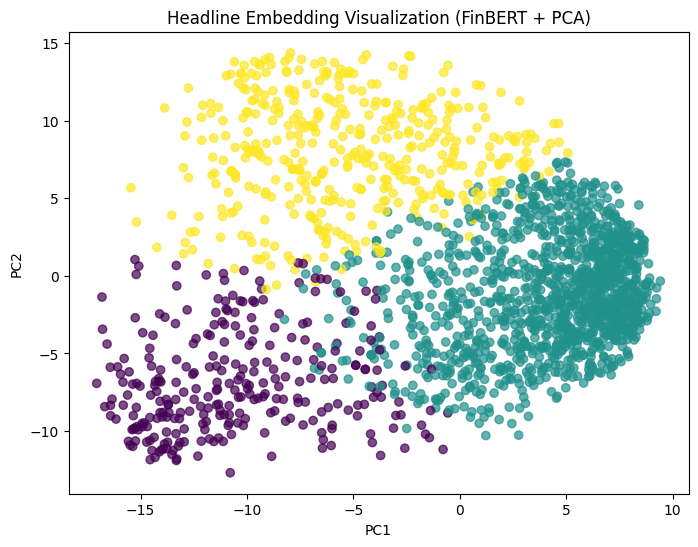


Class distribution in our dataset:
sentiment
neutral     1172782
positive     397516
negative     275261
Name: count, dtype: int64

Proportions:
sentiment
neutral     0.635462
positive    0.215391
negative    0.149148
Name: count, dtype: float64


In [120]:

print("\nCreating embedding visualization sample...")
sample_size = 2000
df_sample = df.dropna(subset=["headline"]).sample(min(sample_size, len(df)), random_state=42)
texts_sample = df_sample["headline"].tolist()
labels_sample = df_sample["sentiment"].map({"negative":0, "neutral":1, "positive":2}).fillna(1).values

# FinBERT base model for embeddings
finbert_base = AutoModel.from_pretrained(finbert_name)
if device.type == "cuda":
    finbert_base = finbert_base.half()
finbert_base.to(device)
finbert_base.eval()

def get_embeddings(texts, batch_size=64, max_len=48):
    emb_list = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = finbert_tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len
        ).to(device)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            with torch.no_grad():
                outputs = finbert_base(**inputs)

        #sentence embedding
        cls_emb = outputs.last_hidden_state[:,0,:].detach().cpu().numpy()
        emb_list.append(cls_emb)
    return np.vstack(emb_list)

print("Computing embeddings for PCA...")
embeddings = get_embeddings(texts_sample)

print("Running PCA...")
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
scatter = plt.scatter(coords[:,0], coords[:,1], c=labels_sample, alpha=0.7)
plt.title("Headline Embedding Visualization (FinBERT + PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


print("\nClass distribution in our dataset:")
count_sent = df["sentiment"].value_counts()
print(count_sent)
print("\nProportions:")
print(count_sent / count_sent.sum())


Preprocessing

In [121]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

path = "/content/drive/MyDrive/NLP_Final_Project/financial_news_headlines.csv"
df = pd.read_csv(path)
print("Original shape:", df.shape)
print(df.head())


Original shape: (1845559, 7)
   Unnamed: 0                                           headline  \
0           2  Agilent Technologies Announces Pricing of $5……...   
1           3  Agilent (A) Gears Up for Q2 Earnings: What's i...   
2           4  J.P. Morgan Asset Management Announces Liquida...   
3           5  Pershing Square Capital Management, L.P. Buys ...   
4           6  Agilent Awards Trilogy Sciences with a Golden ...   

                                                 url  publisher        date  \
0  http://www.gurufocus.com/news/1153187/agilent-...  GuruFocus  2020-06-01   
1  http://www.zacks.com/stock/news/931205/agilent...      Zacks  2020-05-18   
2  http://www.gurufocus.com/news/1138923/jp-morga...  GuruFocus  2020-05-15   
3  http://www.gurufocus.com/news/1138704/pershing...  GuruFocus  2020-05-15   
4  http://www.gurufocus.com/news/1134012/agilent-...  GuruFocus  2020-05-12   

  stock sentiment  
0     A   neutral  
1     A   neutral  
2     A  negative  
3     A

In [122]:

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df["headline"] = df["headline"].astype(str).str.strip()
df["sentiment"] = df["sentiment"].str.strip().str.lower()
print("After basic cleaning:", df.shape)
df.head()


After basic cleaning: (1845559, 6)


,headline,url,publisher,date,stock,sentiment
0,Agilent Technologies Announces Pricing of $5……...,http://www.gurufocus.com/news/1153187/agilent-...,GuruFocus,2020-06-01,A,neutral
1,Agilent (A) Gears Up for Q2 Earnings: What's i...,http://www.zacks.com/stock/news/931205/agilent...,Zacks,2020-05-18,A,neutral
2,J.P. Morgan Asset Management Announces Liquida...,http://www.gurufocus.com/news/1138923/jp-morga...,GuruFocus,2020-05-15,A,negative
3,"Pershing Square Capital Management, L.P. Buys ...",http://www.gurufocus.com/news/1138704/pershing...,GuruFocus,2020-05-15,A,neutral
4,Agilent Awards Trilogy Sciences with a Golden ...,http://www.gurufocus.com/news/1134012/agilent-...,GuruFocus,2020-05-12,A,positive


In [123]:
df = df.dropna(subset=["headline", "sentiment"])
df = df[df["headline"].str.len() > 0]
print("After dropping missing/empty:", df.shape)


After dropping missing/empty: (1845559, 6)


In [124]:
df["len_chars"] = df["headline"].str.len()
df["len_tokens_approx"] = df["headline"].str.split().str.len()
print(df["len_tokens_approx"].describe())


count    1.845559e+06
mean     9.181637e+00
std      3.162763e+00
min      1.000000e+00
25%      7.000000e+00
50%      9.000000e+00
75%      1.100000e+01
max      4.000000e+01
Name: len_tokens_approx, dtype: float64


In [125]:
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

df = df[df["sentiment"].isin(label2id.keys())]
df["label_id"] = df["sentiment"].map(label2id)

print(df[["headline", "sentiment", "label_id"]].head())
df["label_id"].value_counts(normalize=True)


                                            headline sentiment  label_id
0  Agilent Technologies Announces Pricing of $5……...   neutral         1
1  Agilent (A) Gears Up for Q2 Earnings: What's i...   neutral         1
2  J.P. Morgan Asset Management Announces Liquida...  negative         0
3  Pershing Square Capital Management, L.P. Buys ...   neutral         1
4  Agilent Awards Trilogy Sciences with a Golden ...  positive         2


,proportion
label_id,
1,0.635462
2,0.215391
0,0.149148


Splitting the Data

In [126]:
X = df["headline"].values
y = df["label_id"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1291891
Val size: 276834
Test size: 276834


In [127]:
train_df = pd.DataFrame({"headline": X_train, "label_id": y_train})
val_df   = pd.DataFrame({"headline": X_val,   "label_id": y_val})
test_df  = pd.DataFrame({"headline": X_test,  "label_id": y_test})

train_df["sentiment"] = train_df["label_id"].map(id2label)
val_df["sentiment"]   = val_df["label_id"].map(id2label)
test_df["sentiment"]  = test_df["label_id"].map(id2label)


In [128]:
print("Train distribution:")
print(train_df["sentiment"].value_counts(normalize=True))

print("\nVal distribution:")
print(val_df["sentiment"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["sentiment"].value_counts(normalize=True))


Train distribution:
sentiment
neutral     0.635462
positive    0.215390
negative    0.149148
Name: proportion, dtype: float64

Val distribution:
sentiment
neutral     0.635460
positive    0.215393
negative    0.149147
Name: proportion, dtype: float64

Test distribution:
sentiment
neutral     0.635464
positive    0.215389
negative    0.149147
Name: proportion, dtype: float64


In [129]:
out_dir = "/content/drive/MyDrive/NLP_Final_Project/processed"

import os
os.makedirs(out_dir, exist_ok=True)

train_df.to_csv(f"{out_dir}/train_clean.csv", index=False)
val_df.to_csv(f"{out_dir}/val_clean.csv", index=False)
test_df.to_csv(f"{out_dir}/test_clean.csv", index=False)

print("Saved to:", out_dir)


Saved to: /content/drive/MyDrive/NLP_Final_Project/processed


In [130]:
import pandas as pd

base_dir = "/content/drive/MyDrive/NLP_Final_Project/processed"

train_df = pd.read_csv(f"{base_dir}/train_clean.csv")
val_df   = pd.read_csv(f"{base_dir}/val_clean.csv")
test_df  = pd.read_csv(f"{base_dir}/test_clean.csv")

print(train_df.head(10))
print(train_df.columns)


                                            headline  label_id sentiment
0  Top Ranked Growth Stocks to Buy for December 16th         1   neutral
1  REITs April Rain: 18.7% Yield, 34.95% Upside, ...         1   neutral
2  Calton & Associates, Inc. Buys iShares Edge MS...         1   neutral
3  Worthington Industries Earns Recognition as a ...         2  positive
4  Itron (ITRI) Q1 2015 Results - Earnings Call W...         1   neutral
5  Freddie Mac sees $2.1T mortgage originations i...         1   neutral
6  Zacks Industry Outlook Highlights: Xcel Energy...         1   neutral
7                       Post-earnings dip for Kroger         0  negative
8     CSX Beats Earnings Expectations - Analyst Blog         2  positive
9  Look Beyond Profit, Bet on 4 Stocks With Risin...         1   neutral
Index(['headline', 'label_id', 'sentiment'], dtype='object')


In [ ]:
X_train = train_df["headline"].values
y_train = train_df["label_id"].values

X_val   = val_df["headline"].values
y_val   = val_df["label_id"].values

X_test  = test_df["headline"].values
y_test  = test_df["label_id"].values


Logistic Regression

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shapes:")
print(" Train:", X_train_tfidf.shape)
print(" Val:  ", X_val_tfidf.shape)
print(" Test: ", X_test_tfidf.shape)

target_names = ["negative", "neutral", "positive"]

lr_clf = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    solver="saga",
    multi_class="multinomial",
    class_weight="balanced",
    C=1.0
)

print("\nTraining Logistic Regression...")
lr_clf.fit(X_train_tfidf, y_train)

y_pred_lr = lr_clf.predict(X_test_tfidf)

print("\n=== Logistic Regression (TF-IDF) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_lr, target_names=target_names))



TF-IDF shapes:
 Train: (1291891, 50000)
 Val:   (276834, 50000)
 Test:  (276834, 50000)

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Logistic Regression (TF-IDF) ===
Accuracy: 0.8658943626866642

Classification Report:
               precision    recall  f1-score   support

    negative       0.72      0.88      0.79     41289
     neutral       0.96      0.86      0.91    175918
    positive       0.77      0.87      0.81     59627

    accuracy                           0.87    276834
   macro avg       0.81      0.87      0.84    276834
weighted avg       0.88      0.87      0.87    276834



LSTM

In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
import numpy as np



MAX_VOCAB = 30_000
MAX_LEN   = 30

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print("\nPadded shapes:")
print(" Train:", X_train_pad.shape)
print(" Val:  ", X_val_pad.shape)
print(" Test: ", X_test_pad.shape)

NUM_CLASSES = len(np.unique(y_train))

# ---- Class Weights (for imbalance) ----
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}
print("\nClass weights:", class_weights)




EMBED_DIM = 100
LSTM_UNITS = 64

lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

print("\nBiLSTM model summary:")
lstm_model.summary()
BATCH_SIZE = 128
EPOCHS = 8

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_lstm_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, early_stopping_cb],
    verbose=1
)

y_pred_lstm_probs = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)

print("\n=== BiLSTM (tuned) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_lstm, target_names=target_names))


Padded shapes:
 Train: (1291891, 30)
 Val:   (276834, 30)
 Test:  (276834, 30)

Class weights: {0: np.float64(2.234916071128918), 1: np.float64(0.524553148173187), 2: np.float64(1.5475770349899316)}

BiLSTM model summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

10093/10093 ━━━━━━━━━━━━━━━━━━━━ 85s 8ms/step - accuracy: 0.8136 - loss: 0.4447 - val_accuracy: 0.8901 - val_loss: 0.2695
Epoch 2/8
10090/10093 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8906 - loss: 0.2538
Epoch 2: val_accuracy improved from 0.89005 to 0.89817, saving model to best_lstm_model.h5


10093/10093 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.8906 - loss: 0.2538 - val_accuracy: 0.8982 - val_loss: 0.2484
Epoch 3/8
10090/10093 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9151 - loss: 0.1970
Epoch 3: val_accuracy improved from 0.89817 to 0.91217, saving model to best_lstm_model.h5


10093/10093 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.9151 - loss: 0.1970 - val_accuracy: 0.9122 - val_loss: 0.2316
Epoch 4/8
10091/10093 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9316 - loss: 0.1593
Epoch 4: val_accuracy improved from 0.91217 to 0.91459, saving model to best_lstm_model.h5


10093/10093 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.9316 - loss: 0.1593 - val_accuracy: 0.9146 - val_loss: 0.2394
Epoch 5/8
10092/10093 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9430 - loss: 0.1320
Epoch 5: val_accuracy improved from 0.91459 to 0.92378, saving model to best_lstm_model.h5


10093/10093 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.9430 - loss: 0.1320 - val_accuracy: 0.9238 - val_loss: 0.2359
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.
8652/8652 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step

=== BiLSTM (tuned) ===
Accuracy: 0.9104445263226337

Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.92      0.87     41289
     neutral       0.98      0.90      0.94    175918
    positive       0.81      0.94      0.87     59627

    accuracy                           0.91    276834
   macro avg       0.87      0.92      0.89    276834
weighted avg       0.92      0.91      0.91    276834



Transformer Model

In [ ]:
!pip install -q --upgrade transformers accelerate datasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 37.5 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

base_dir = "/content/drive/MyDrive/NLP_Final_Project/processed"

train_df = pd.read_csv(f"{base_dir}/train_clean.csv")
val_df   = pd.read_csv(f"{base_dir}/val_clean.csv")
test_df  = pd.read_csv(f"{base_dir}/test_clean.csv")

print(train_df.head())
print(train_df["sentiment"].value_counts(normalize=True))


                                            headline  label_id sentiment
0  Top Ranked Growth Stocks to Buy for December 16th         1   neutral
1  REITs April Rain: 18.7% Yield, 34.95% Upside, ...         1   neutral
2  Calton & Associates, Inc. Buys iShares Edge MS...         1   neutral
3  Worthington Industries Earns Recognition as a ...         2  positive
4  Itron (ITRI) Q1 2015 Results - Earnings Call W...         1   neutral
sentiment
neutral     0.635462
positive    0.215390
negative    0.149148
Name: proportion, dtype: float64


In [ ]:

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}
target_names = ["negative", "neutral", "positive"]

train_df["label_id"] = train_df["label_id"].astype(int)
val_df["label_id"]   = val_df["label_id"].astype(int)
test_df["label_id"]  = test_df["label_id"].astype(int)
train_df = train_df.rename(columns={"label_id": "label"})
val_df   = val_df.rename(columns={"label_id": "label"})
test_df  = test_df.rename(columns={"label_id": "label"})


In [ ]:
MAX_TRAIN = 300_000
MAX_VAL   = 50_000
MAX_TEST  = 50_000

if len(train_df) > MAX_TRAIN:
    train_df = train_df.sample(MAX_TRAIN, random_state=42)

if len(val_df) > MAX_VAL:
    val_df = val_df.sample(MAX_VAL, random_state=42)

if len(test_df) > MAX_TEST:
    test_sample_df = test_df.sample(MAX_TEST, random_state=42)
else:
    test_sample_df = test_df

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_sample_df))


Train size: 300000
Val size:   50000
Test size:  50000


In [ ]:
train_ds = Dataset.from_pandas(train_df[["headline", "label"]])
val_ds   = Dataset.from_pandas(val_df[["headline", "label"]])
test_ds  = Dataset.from_pandas(test_sample_df[["headline", "label"]])


Transformer Model Training

In [ ]:
def train_and_eval_transformer(model_name, num_epochs=3, max_length=64):
    print(f"\n==============================")
    print(f"Training model: {model_name}")
    print(f"==============================")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_fn(batch):
        return tokenizer(
            batch["headline"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    train_tok = train_ds.map(tokenize_fn, batched=True)
    val_tok   = val_ds.map(tokenize_fn, batched=True)
    test_tok  = test_ds.map(tokenize_fn, batched=True)

    train_tok = train_tok.remove_columns(["headline"])
    val_tok   = val_tok.remove_columns(["headline"])
    test_tok  = test_tok.remove_columns(["headline"])

    train_tok.set_format("torch")
    val_tok.set_format("torch")
    test_tok.set_format("torch")


    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        label2id=label2id,
        id2label=id2label
    )


    safe_name = model_name.replace("/", "_")
    out_dir = f"/content/transformer_{safe_name}"

    training_args = TrainingArguments(
        output_dir=out_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        save_total_limit=1,
        logging_steps=500,
        logging_dir=f"{out_dir}/logs",
        report_to="none"
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(
            labels, preds, average="weighted"
        )
        return {
            "accuracy": acc,
            "f1_weighted": f1,
            "precision_weighted": prec,
            "recall_weighted": rec
        }

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()
    test_results = trainer.predict(test_tok)
    logits = test_results.predictions
    y_true = test_results.label_ids
    y_pred = np.argmax(logits, axis=-1)

    print("\n=== Test set metrics ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification report:\n",
          classification_report(y_true, y_pred, target_names=target_names))

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "report": classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    }


new

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

def train_and_eval_transformer(model_name, num_epochs=3, max_length=64):
    print(f"\n==============================")
    print(f"Training model: {model_name}")
    print(f"==============================")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_fn(batch):
        return tokenizer(
            batch["headline"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )
    train_tok = train_ds.map(tokenize_fn, batched=True)
    val_tok   = val_ds.map(tokenize_fn, batched=True)
    test_tok  = test_ds.map(tokenize_fn, batched=True)

    train_tok = train_tok.remove_columns(["headline"])
    val_tok   = val_tok.remove_columns(["headline"])
    test_tok  = test_tok.remove_columns(["headline"])
    train_tok.set_format("torch")
    val_tok.set_format("torch")
    test_tok.set_format("torch")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        label2id=label2id,
        id2label=id2label
    )

    safe_name = model_name.replace("/", "_")
    out_dir = f"/content/transformer_{safe_name}"


    training_args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=500,
        logging_dir=f"{out_dir}/logs",
        report_to="none"
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(
            labels, preds, average="weighted"
        )
        return {
            "accuracy": acc,
            "f1_weighted": f1,
            "precision_weighted": prec,
            "recall_weighted": rec
        }

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )


    trainer.train()
    print("\n=== Validation metrics ===")
    val_results = trainer.evaluate(eval_dataset=val_tok)
    print(val_results)

    print("\n=== Test set metrics ===")
    test_results = trainer.predict(test_tok)
    logits = test_results.predictions
    y_true = test_results.label_ids
    y_pred = np.argmax(logits, axis=-1)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification report:\n",
          classification_report(y_true, y_pred, target_names=target_names))

    return {
        "val_results": val_results,
        "test_accuracy": accuracy_score(y_true, y_pred),
        "test_report": classification_report(
            y_true, y_pred, target_names=target_names, output_dict=True
        )
    }


In [ ]:
model_names = [
    "distilbert-base-uncased",
    "bert-base-uncased",
    "ProsusAI/finbert"
]

all_results = {}

for m in model_names:
    metrics = train_and_eval_transformer(m, num_epochs=3)
    all_results[m] = metrics



Training model: distilbert-base-uncased


Map:   0%|          | 0/300000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-595361959.py:78: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

/tmp/ipython-input-595361959.py:78: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.409800
1000,0.257000
1500,0.244600
2000,0.226400
2500,0.216100
3000,0.210600
3500,0.200300
4000,0.203700
4500,0.195600
5000,0.193700



=== Validation metrics ===


{'eval_loss': 0.19234080612659454, 'eval_accuracy': 0.95728, 'eval_f1_weighted': 0.9574602984852879, 'eval_precision_weighted': 0.9578070099711602, 'eval_recall_weighted': 0.95728, 'eval_runtime': 43.2126, 'eval_samples_per_second': 1157.069, 'eval_steps_per_second': 18.097, 'epoch': 3.0}

=== Test set metrics ===
Accuracy: 0.95724

Classification report:
               precision    recall  f1-score   support

    negative       0.92      0.94      0.93      7501
     neutral       0.98      0.96      0.97     31568
    positive       0.92      0.95      0.94     10931

    accuracy                           0.96     50000
   macro avg       0.94      0.95      0.95     50000
weighted avg       0.96      0.96      0.96     50000



In [ ]:
import os
import shutil


project_path = "/content/drive/MyDrive/NLP_Final_Project"
models_dir = os.path.join(project_path, "models")
os.makedirs(models_dir, exist_ok=True)
print(f"📂 Target Folder: {models_dir}")
temp_folders = [
    "transformer_distilbert-base-uncased",
    "transformer_bert-base-uncased",
    "transformer_ProsusAI_finbert"
]


print("\n Starting Backup...")
for folder_name in temp_folders:
    source_path = f"/content/{folder_name}"
    dest_path = os.path.join(models_dir, folder_name)

    if os.path.exists(source_path):
        if os.path.exists(dest_path):
            shutil.rmtree(dest_path)

        shutil.move(source_path, dest_path)
        print(f"SUCCESSFULLY SAVED: {folder_name}")
    else:
        if os.path.exists(dest_path):
            print(f"Already saved (Source missing, but found in Drive): {folder_name}")
        else:
            print(f"ERROR: Could not find {folder_name}. Did training finish?")

print("\nBackup complete. Your models are safe!")

📂 Target Folder: /content/drive/MyDrive/NLP_Final_Project/models

🚀 Starting Backup...
✅ SUCCESSFULLY SAVED: transformer_distilbert-base-uncased
✅ SUCCESSFULLY SAVED: transformer_bert-base-uncased
✅ SUCCESSFULLY SAVED: transformer_ProsusAI_finbert

Backup complete. Your models are safe!


In [ ]:
import joblib
joblib.dump(tfidf,   os.path.join(models_dir, "tfidf_vectorizer.pkl"))
joblib.dump(lr_clf,  os.path.join(models_dir, "logreg_tfidf.pkl"))
print("Saved Logistic Regression")

Saved Logistic Regression


In [ ]:

bilstm_path = os.path.join(models_dir, "bilstm_model.h5")
lstm_model.save(bilstm_path)
print("Saved BiLSTM model to:", bilstm_path)
from tensorflow.keras.preprocessing.text import tokenizer_from_json
import json

tokenizer_json = tokenizer.to_json()
with open(os.path.join(models_dir, "bilstm_tokenizer.json"), "w") as f:
    f.write(tokenizer_json)

print("Saved BiLSTM tokenizer.")


Saved BiLSTM model to: /content/drive/MyDrive/NLP_Final_Project/models/bilstm_model.h5
Saved BiLSTM tokenizer.


In [ ]:
!ls "/content/drive/MyDrive/NLP_Final_Project/models"

bilstm_model.h5        tfidf_vectorizer.pkl
bilstm_model.keras     transformer_bert-base-uncased
bilstm_tokenizer.json  transformer_distilbert-base-uncased
logreg_tfidf.pkl       transformer_ProsusAI_finbert


In [ ]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models_dir = "/content/drive/MyDrive/NLP_Final_Project/models"
model_map = {
    "DistilBERT": "transformer_distilbert-base-uncased",
    "BERT":       "transformer_bert-base-uncased",
    "FinBERT":    "transformer_ProsusAI_finbert"
}

models_dict = {}

print("Smart-Loading models from Google Drive...")

for display_name, folder_name in model_map.items():
    base_path = os.path.join(models_dir, folder_name)

    if not os.path.exists(base_path):
        print(f"MISSING: {base_path}")
        continue

    subfolders = [f for f in os.listdir(base_path) if f.startswith("checkpoint-")]

    if subfolders:
        subfolders.sort(key=lambda x: int(x.split('-')[1]))
        latest_checkpoint = subfolders[-1]
        final_model_path = os.path.join(base_path, latest_checkpoint)
        print(f"   Found Checkpoints in {display_name}. Loading: {latest_checkpoint}...")
    else:
        final_model_path = base_path
        print(f"   No sub-checkpoints found. Loading from root: {folder_name}...")

    try:
        tokenizer = AutoTokenizer.from_pretrained(final_model_path)
        model = AutoModelForSequenceClassification.from_pretrained(final_model_path)
        model.to(device)
        model.eval()

        models_dict[display_name] = {"model": model, "tokenizer": tokenizer}
        print(f"Success! Loaded {display_name}")
    except Exception as e:
        print(f"ERROR loading {display_name}: {e}")

print(f"\nReady! Loaded {len(models_dict)}/3 models.")

⬇️  Smart-Loading models from Google Drive...
   Found Checkpoints in DistilBERT. Loading: checkpoint-28125...
   ✅ Success! Loaded DistilBERT
   Found Checkpoints in BERT. Loading: checkpoint-28125...
   ✅ Success! Loaded BERT
   Found Checkpoints in FinBERT. Loading: checkpoint-28125...
   ✅ Success! Loaded FinBERT

Ready! Loaded 3/3 models.


In [ ]:

print("\n\n SPEED TEST (Headlines per Second)")
print("-" * 50)

def measure_speed(model, tokenizer, texts, batch_size=32):

    sample = texts[:1000]
    batches = [sample[i:i+batch_size] for i in range(0, len(sample), batch_size)]

    start = time.time()
    with torch.no_grad():
        for batch in batches:
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=64, return_tensors="pt").to(device)
            model(**inputs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.time()
    return len(sample) / (end - start)

test_texts = [x['headline'] for x in test_ds]

for name, data in models_dict.items():
    speed = measure_speed(data['model'], data['tokenizer'], test_texts)
    print(f"{name:12} : {speed:.2f} headlines/sec")





 EXPERIMENT 1: SPEED TEST (Headlines per Second)
--------------------------------------------------
DistilBERT   : 3449.57 headlines/sec
BERT         : 2343.14 headlines/sec
FinBERT      : 2349.78 headlines/sec


Testing the model using tricky Sentence

In [ ]:

print("\n\n TEST Using Tricky Sentence")
print("-" * 50)
print("Checking how models handle contradictory financial phrasing...")

tricky_sentences = [
    "The company reported a net loss, but it was smaller than expected.",
    "Revenue increased 50%, but the CEO warned of supply chain issues.",
    "Operating costs soared, eating into the profit margins.",
    "The merger discussions have been paused indefinitely."
]

for text in tricky_sentences:
    print(f"\n'{text}'")
    for name, data in models_dict.items():
        inputs = data['tokenizer'](text, return_tensors="pt", truncation=True).to(device)
        with torch.no_grad():
            logits = data['model'](**inputs).logits
            probs = F.softmax(logits, dim=-1)
            pred_idx = torch.argmax(probs).item()
            conf = probs[0][pred_idx].item()
            labels = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
            label_str = labels[pred_idx]

            print(f"   {name:12} -> {label_str} ({conf:.1%})")






 EXPERIMENT 2: LINGUISTIC STRESS TEST
--------------------------------------------------
Checking how models handle contradictory financial phrasing...

'The company reported a net loss, but it was smaller than expected.'
   DistilBERT   -> NEGATIVE (99.9%)
   BERT         -> NEGATIVE (100.0%)
   FinBERT      -> NEGATIVE (100.0%)

'Revenue increased 50%, but the CEO warned of supply chain issues.'
   DistilBERT   -> NEGATIVE (99.3%)
   BERT         -> NEGATIVE (99.7%)
   FinBERT      -> NEGATIVE (99.9%)

'Operating costs soared, eating into the profit margins.'
   DistilBERT   -> NEGATIVE (99.4%)
   BERT         -> NEGATIVE (99.9%)
   FinBERT      -> NEGATIVE (100.0%)

'The merger discussions have been paused indefinitely.'
   DistilBERT   -> NEGATIVE (85.8%)
   BERT         -> NEGATIVE (75.0%)
   FinBERT      -> NEUTRAL (99.5%)


Ensemble Accuracy

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score

print("\n\n ENSEMBLE ACCURACY")
print("-" * 50)

def prepare_test_set(tokenizer, dataset):
    """
    Re-creates test_tok for a specific tokenizer.
    FIX: Only removes the raw text column, preserves input_ids.
    """
    def tokenize_fn(batch):
        return tokenizer(
            batch["headline"],
            truncation=True,
            padding="max_length",
            max_length=64
        )

    tokenized = dataset.map(tokenize_fn, batched=True)

    if "headline" in tokenized.column_names:
        tokenized = tokenized.remove_columns(["headline"])

    tokenized.set_format("torch")
    return tokenized

def get_probs(model, tokenizer, dataset):
    test_tok_specific = prepare_test_set(tokenizer, dataset)
    args = TrainingArguments(output_dir="tmp", per_device_eval_batch_size=64, report_to="none")
    trainer = Trainer(model=model, args=args, tokenizer=tokenizer)

    preds = trainer.predict(test_tok_specific)
    return F.softmax(torch.tensor(preds.predictions), dim=-1).numpy(), preds.label_ids

if len(models_dict) == 3:
    print("Calculating Ensemble predictions (Soft Voting)...")

    print("   -> Getting predictions from DistilBERT...")
    p1, y_true = get_probs(models_dict['DistilBERT']['model'], models_dict['DistilBERT']['tokenizer'], test_ds)

    print("   -> Getting predictions from BERT...")
    p2, _      = get_probs(models_dict['BERT']['model'],       models_dict['BERT']['tokenizer'],       test_ds)

    print("   -> Getting predictions from FinBERT...")
    p3, _      = get_probs(models_dict['FinBERT']['model'],    models_dict['FinBERT']['tokenizer'],    test_ds)

    avg_probs = (p1 + p2 + p3) / 3
    ensemble_preds = np.argmax(avg_probs, axis=1)


    acc_distil = accuracy_score(y_true, np.argmax(p1, axis=1))
    acc_bert   = accuracy_score(y_true, np.argmax(p2, axis=1))
    acc_fin    = accuracy_score(y_true, np.argmax(p3, axis=1))
    acc_ens    = accuracy_score(y_true, ensemble_preds)

    print(f"\nDistilBERT Accuracy: {acc_distil:.5f}")
    print(f"BERT Accuracy:       {acc_bert:.5f}")
    print(f"FinBERT Accuracy:    {acc_fin:.5f}")
    print("-" * 30)
    print(f" ENSEMBLE Accuracy:  {acc_ens:.5f}")
else:
    print("Skipping Ensemble: Need all 3 models loaded.")



🧪 EXPERIMENT 3: ENSEMBLE ACCURACY
--------------------------------------------------
Calculating Ensemble predictions (Soft Voting)...
   -> Getting predictions from DistilBERT...


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

/tmp/ipython-input-1894686032.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, tokenizer=tokenizer)


   -> Getting predictions from BERT...


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

/tmp/ipython-input-1894686032.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, tokenizer=tokenizer)


   -> Getting predictions from FinBERT...


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

/tmp/ipython-input-1894686032.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, tokenizer=tokenizer)



DistilBERT Accuracy: 0.94394
BERT Accuracy:       0.95048
FinBERT Accuracy:    0.95724
------------------------------
🚀 ENSEMBLE Accuracy:  0.95544


In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 111.7 MB/s eta 0:00:00


Random real data for testing

In [ ]:

import pandas as pd
data = [
    {"headline": "Apple smashes earnings expectations but warns of supply chain constraints.", "sentiment": "positive"},
    {"headline": "The merger talks have stalled indefinitely due to regulatory pushback.", "sentiment": "negative"},
    {"headline": "The Federal Reserve left interest rates unchanged at 5.25%.", "sentiment": "neutral"},
    {"headline": "Operating loss narrowed to $5 million from $12 million a year ago.", "sentiment": "positive"},
    {"headline": "CEO steps down amid allegations of accounting irregularities.", "sentiment": "negative"},
    {"headline": "Markets opened flat as investors await inflation data.", "sentiment": "neutral"},
    {"headline": "Company announces 10% workforce reduction to streamline operations.", "sentiment": "negative"},
    {"headline": "New product line expected to add $2B in revenue by Q4.", "sentiment": "positive"},
    {"headline": "Competitor's stock soared while we remained stagnant.", "sentiment": "neutral"},
    {"headline": "Despite the revenue beat, EPS missed targets by a wide margin.", "sentiment": "negative"}
]

df = pd.DataFrame(data)
df.to_csv("/content/drive/MyDrive/NLP_Final_Project/random_real_headlines.csv", index=False)
print("Created data/random_real_headlines.csv")

Created data/random_real_headlines.csv


In [ ]:
!wget -q -O - ipv4.icanhazip.com

35.198.232.27


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import json
import torch
import os
import joblib

from transformers import AutoTokenizer, AutoModelForSequenceClassification
st.set_page_config(page_title="Financial Sentiment Lab", page_icon="📈", layout="wide")
# PATHS
BASE_DIR = "/content/drive/MyDrive/NLP_Final_Project"
MODELS_DIR = os.path.join(BASE_DIR, "models")

st.markdown("""
    <style>
    .sentiment-pill { display: inline-block; padding: 0.25rem 0.75rem; border-radius: 999px; font-size: 0.85rem; font-weight: 700; color: white; text-transform: uppercase; }
    .sentiment-negative { background-color: #e74c3c; }
    .sentiment-neutral  { background-color: #95a5a6; }
    .sentiment-positive { background-color: #27ae60; }
    .model-card { border-radius: 10px; padding: 10px; background-color: white; border: 1px solid #e0e0e0; margin-bottom: 10px; font-size: 0.9rem; }
    .model-title { font-weight: bold; font-size: 1rem; color: #2c3e50; margin-bottom: 5px; }
    </style>
""", unsafe_allow_html=True)

ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
@st.cache_data
def load_data():
    datasets = {}
    path_project = os.path.join(BASE_DIR, "financial_news_headlines.csv")
    path_phrase = os.path.join(BASE_DIR, "Sentences_AllAgree.txt")
    path_random = os.path.join(BASE_DIR, "random_real_headlines.csv")

    try:
        if os.path.exists(path_project): datasets["Project Data"] = pd.read_csv(path_project).dropna()
        if os.path.exists(path_phrase): datasets["Financial PhraseBank"] = pd.read_csv(path_phrase, sep="@", names=["headline", "sentiment"], encoding="latin-1").dropna()
        if os.path.exists(path_random): datasets["Real World Random"] = pd.read_csv(path_random).dropna()
        else: datasets["Real World Random"] = pd.DataFrame([{"headline": "Market crashes.", "sentiment": "negative"}])
    except: pass
    return datasets
@st.cache_resource
def load_lr_resources():
    try:
        vec_path = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
        model_path = os.path.join(MODELS_DIR, "logreg_tfidf.pkl")
        if os.path.exists(vec_path) and os.path.exists(model_path):
            return joblib.load(vec_path), joblib.load(model_path)
        return None, None
    except: return None, None

@st.cache_resource
def load_transformer_model(model_folder_name):
    base_path = os.path.join(MODELS_DIR, model_folder_name)
    if not os.path.exists(base_path): return None, None, None

    final_path = base_path
    if not os.path.exists(os.path.join(base_path, "config.json")):
        subfolders = [f for f in os.listdir(base_path) if f.startswith("checkpoint-")]
        if subfolders:
            subfolders.sort(key=lambda x: int(x.split('-')[1]))
            final_path = os.path.join(base_path, subfolders[-1])
        else:
            return None, None, None

    try:
        tokenizer = AutoTokenizer.from_pretrained(final_path)
        model = AutoModelForSequenceClassification.from_pretrained(final_path)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        model.eval()
        return tokenizer, model, device
    except: return None, None, None

def predict_lr(text, vec, model):
    if not model: return "N/A", 0.0
    try:
        vec_text = vec.transform([text])
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(vec_text)[0]
            pred_idx = np.argmax(probs)
            return ID2LABEL[pred_idx], probs[pred_idx]
        return "N/A", 0.0
    except: return "Error", 0.0

def predict_transformer(text, tokenizer, model, device):
    if not model: return "N/A", 0.0
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.nn.functional.softmax(logits, dim=-1)[0]
            conf, pred_idx = torch.max(probs, dim=-1)
        return ID2LABEL[pred_idx.item()], conf.item()
    except: return "Error", 0.0

def get_pill_html(label):
    if label in ["N/A", "Error"]: return '<span style="color:gray;">Not Found</span>'
    return f'<span class="sentiment-pill sentiment-{label}">{label}</span>'

# MAIN UI
st.sidebar.title("⚙️ Settings")
data_map = load_data()

if not data_map:
    st.error(f"No data found in {BASE_DIR}")
    st.stop()

dataset_choice = st.sidebar.selectbox("Select Data", list(data_map.keys()))
df = data_map[dataset_choice]
if 'sentence' in df.columns: df = df.rename(columns={'sentence': 'headline'})
if 'sentiment' not in df.columns: df['sentiment'] = 'unknown'

sample_n = st.sidebar.slider("Sample Size", 5, 50, 10)
df_sample = df.sample(min(len(df), sample_n), random_state=42).reset_index(drop=True)

st.title("📈 news Headline Sentiment Classifier Demo APP")
st.markdown(f"**Dataset:** {dataset_choice}")

selected_idx = st.selectbox("Choose Headline:", df_sample.index, format_func=lambda x: f"{df_sample.iloc[x]['headline'][:90]}...")
selected_row = df_sample.iloc[selected_idx]
st.info(f"**Headline:** {selected_row['headline']}")

with st.spinner("Loading models..."):
    vec_lr, model_lr = load_lr_resources()
    distil_tok, distil_model, distil_dev = load_transformer_model("transformer_distilbert-base-uncased")
    bert_tok, bert_model, bert_dev = load_transformer_model("transformer_bert-base-uncased")
    fin_tok, fin_model, fin_dev = load_transformer_model("transformer_ProsusAI_finbert")

c0, c1, c2, c3 = st.columns(4)

p_lr, c_lr = predict_lr(selected_row['headline'], vec_lr, model_lr)
p_dist, c_dist = predict_transformer(selected_row['headline'], distil_tok, distil_model, distil_dev)
p_bert, c_bert = predict_transformer(selected_row['headline'], bert_tok, bert_model, bert_dev)
p_fin, c_fin = predict_transformer(selected_row['headline'], fin_tok, fin_model, fin_dev)

with c0: st.markdown(f"""<div class="model-card"><div class="model-title">Logistic Reg</div><div>{get_pill_html(p_lr)}</div><small>{c_lr:.1%}</small></div>""", unsafe_allow_html=True)
with c1: st.markdown(f"""<div class="model-card"><div class="model-title">DistilBERT</div><div>{get_pill_html(p_dist)}</div><small>{c_dist:.1%}</small></div>""", unsafe_allow_html=True)
with c2: st.markdown(f"""<div class="model-card"><div class="model-title">BERT Base</div><div>{get_pill_html(p_bert)}</div><small>{c_bert:.1%}</small></div>""", unsafe_allow_html=True)
with c3: st.markdown(f"""<div class="model-card"><div class="model-title" style="color:#d35400">FinBERT </div><div>{get_pill_html(p_fin)}</div><small>{c_fin:.1%}</small></div>""", unsafe_allow_html=True)

if st.checkbox("Show Batch Analysis"):
    results = []
    for idx, row in df_sample.iterrows():
        txt = row['headline']
        p_lr, _ = predict_lr(txt, vec_lr, model_lr)
        p_dist, _ = predict_transformer(txt, distil_tok, distil_model, distil_dev)
        p_fin, _ = predict_transformer(txt, fin_tok, fin_model, fin_dev)
        results.append({"Headline": txt, "LR": p_lr, "DistilBERT": p_dist, "FinBERT": p_fin})
    st.dataframe(pd.DataFrame(results))

Overwriting app.py


In [ ]:
!npm install -g localtunnel
# Get your Password
print("Your Password/IP is:")
!wget -q -O - ipv4.icanhazip.com


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 1s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋Your Password/IP is:
35.198.232.27


In [ ]:
import time
import subprocess
import os


if not os.path.exists("cloudflared"):
    !wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
    !chmod +x cloudflared
print("Starting Streamlit...")
!nohup streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

print("Starting Cloudflare Tunnel...")
!nohup ./cloudflared tunnel --url http://localhost:8501 > tunnel.log 2>&1 &

time.sleep(8)
print("\n CLICK THE LINK BELOW TO OPEN YOUR APP:\n")
!grep -o 'https://.*\.trycloudflare.com' tunnel.log

Starting Streamlit...
Starting Cloudflare Tunnel...

 CLICK THE LINK BELOW TO OPEN YOUR APP:

https://newman-inn-hayes-furnishings.trycloudflare.com
